# IBM HR Attrition Prediction

## 1. End-to-End Modeling Pipeline

Loaded data from: /content/WA_Fn-UseC_-HR-Employee-Attrition.csv
Raw shape: (1470, 35)

===== DATA AUDIT =====
{
  "shape": [
    1470,
    35
  ],
  "target_col": "Attrition",
  "missing_total": 0,
  "duplicate_rows": 0,
  "constant_cols": [
    "EmployeeCount",
    "Over18",
    "StandardHours"
  ],
  "id_like_cols": [
    "EmployeeNumber"
  ],
  "target_distribution_raw": {
    "No": 1233,
    "Yes": 237
  }
}

===== BASIC TARGET STATS =====
Target distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Positive rate (Attrition=Yes): 0.1612


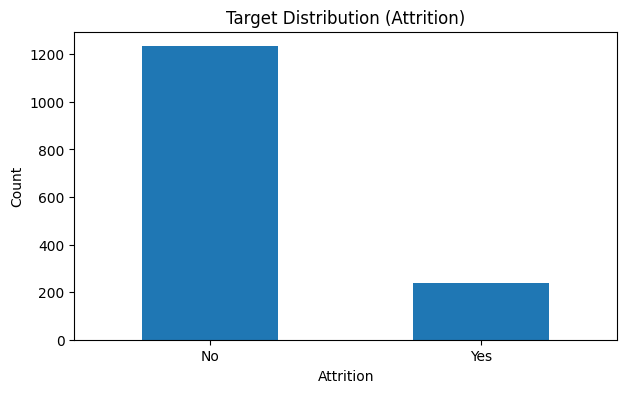

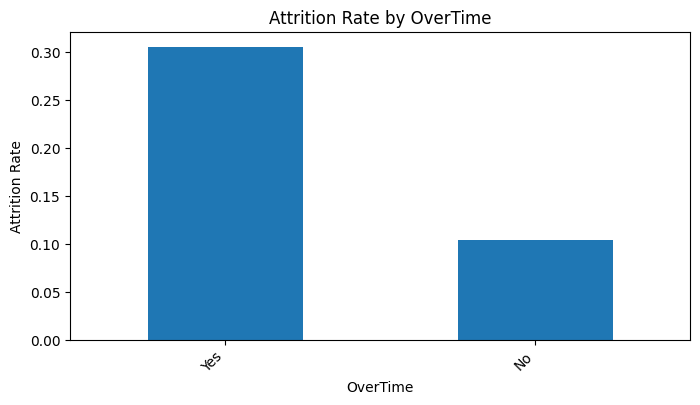


Attrition rate by OverTime:
OverTime
Yes    0.3053
No     0.1044
Name: AttritionFlag, dtype: float64


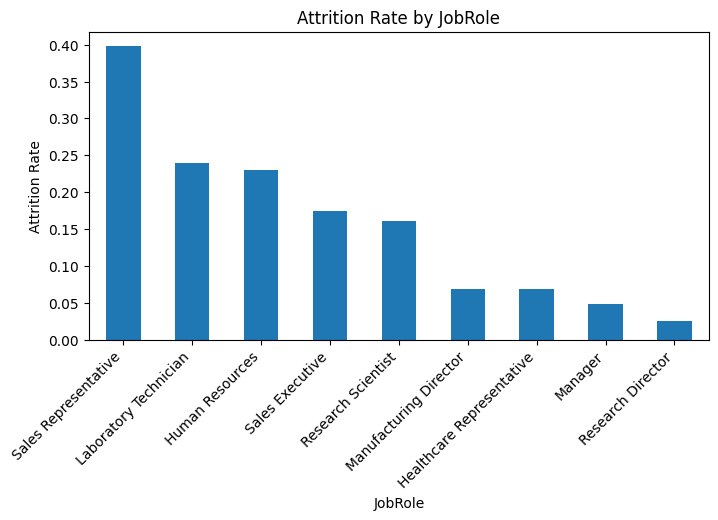


Attrition rate by JobRole:
JobRole
Sales Representative         0.3976
Laboratory Technician        0.2394
Human Resources              0.2308
Sales Executive              0.1748
Research Scientist           0.1610
Manufacturing Director       0.0690
Healthcare Representative    0.0687
Manager                      0.0490
Research Director            0.0250
Name: AttritionFlag, dtype: float64


<Figure size 600x400 with 0 Axes>

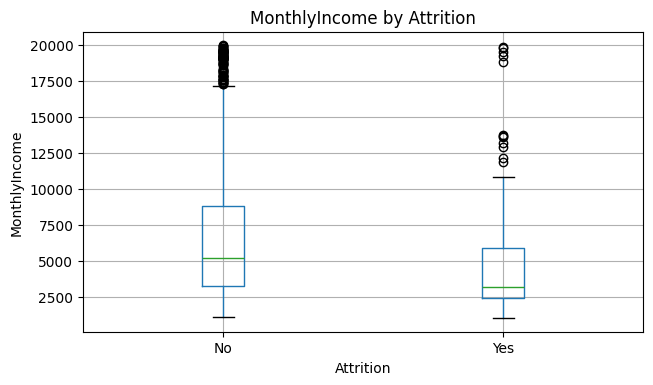


MonthlyIncome grouped summary:
              mean  median
Attrition                 
No         6832.74  5204.0
Yes        4787.09  3202.0


<Figure size 600x400 with 0 Axes>

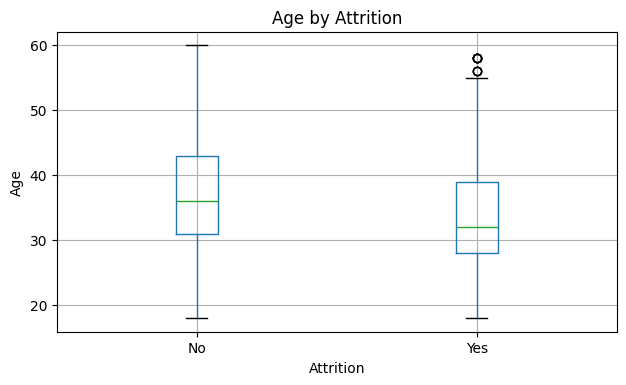


Age grouped summary:
            mean  median
Attrition               
No         37.56    36.0
Yes        33.61    32.0

Dropping invalid / constant / ID-like columns: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Numeric columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

===== SPLIT INFO =====
Train_val shape: (1249, 30)
Test shape: (221, 30)
Train_val positive rate: 0.1609
Test positive rate: 0.1629
Saved split_artifacts.json

[XGBoost] scale_pos_we

,model,pr_auc,roc_auc,f1,recall,precision,accuracy,balanced_accuracy,threshold
0,LR_unweighted,0.628750,0.832156,0.533762,0.412935,0.754545,0.883907,0.693586,0.5
1,LR_balanced,0.597644,0.824541,0.498316,0.736318,0.376590,0.761409,0.751270,0.5
2,XGB_scale_pos_weight,0.571704,0.807086,0.546479,0.482587,0.629870,0.871097,0.714099,0.5
3,RF_balanced,0.502739,0.783250,0.416938,0.318408,0.603774,0.856685,0.639166,0.5
4,Dummy_prior,0.160221,0.497439,0.000000,0.000000,0.000000,0.839071,0.500000,0.5



Selected best model by OOF ranking: LR_unweighted

===== CROSS-VALIDATE SUMMARY (MEAN ± STD) =====
[CV] Running cross_validate for: Dummy_prior
[CV] Running cross_validate for: LR_unweighted
[CV] Running cross_validate for: LR_balanced
[CV] Running cross_validate for: RF_balanced
[CV] Running cross_validate for: XGB_scale_pos_weight

===== CROSS-VALIDATE SUMMARY TABLE =====


,model,pr_auc_mean_std,roc_auc_mean_std,f1_mean_std,recall_mean_std,precision_mean_std,balanced_accuracy_mean_std,accuracy_mean_std
0,LR_unweighted,0.6411 ± 0.0545,0.8329 ± 0.0285,0.5316 ± 0.0870,0.4123 ± 0.0755,0.7550 ± 0.1090,0.6933 ± 0.0419,0.8839 ± 0.0198
1,LR_balanced,0.6058 ± 0.0594,0.8256 ± 0.0333,0.4975 ± 0.0368,0.7359 ± 0.0675,0.3761 ± 0.0262,0.7510 ± 0.0336,0.7614 ± 0.0144
2,XGB_scale_pos_weight,0.5827 ± 0.0618,0.8081 ± 0.0442,0.5446 ± 0.0581,0.4822 ± 0.0646,0.6283 ± 0.0510,0.7139 ± 0.0333,0.8711 ± 0.0129
3,RF_balanced,0.5285 ± 0.0975,0.7874 ± 0.0515,0.4147 ± 0.0966,0.3177 ± 0.0800,0.6065 ± 0.1343,0.6388 ± 0.0448,0.8567 ± 0.0224
4,Dummy_prior,0.1609 ± 0.0016,0.5000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.5000 ± 0.0000,0.8391 ± 0.0016



===== THRESHOLD SELECTION (OOF OF SELECTED MODEL ONLY) =====


,policy,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,default_0.50,0.50,0.883907,0.693586,0.754545,0.412935,0.533762,0.832156,0.62875
1,best_f1,0.42,0.885508,0.736760,0.693333,0.517413,0.592593,0.832156,0.62875
2,recall_floor_0.60,0.32,0.862290,0.757102,0.568075,0.601990,0.584541,0.832156,0.62875



Report-friendly threshold policy: best_f1
Chosen report threshold: 0.4200

===== FINAL FIT ON TRAIN_VAL =====

===== TEST THRESHOLD COMPARISON =====


,policy,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,best_f1,0.42,0.873303,0.700601,0.666667,0.444444,0.533333,0.838288,0.628241
1,default_0.50,0.50,0.868778,0.664339,0.684211,0.361111,0.472727,0.838288,0.628241
2,recall_floor_0.60,0.32,0.832579,0.698649,0.486486,0.500000,0.493151,0.838288,0.628241



===== FINAL TEST METRICS (REPORT VERSION) =====
{
  "threshold": 0.42000000000000004,
  "accuracy": 0.8733031674208145,
  "balanced_accuracy": 0.7006006006006006,
  "precision": 0.6666666666666666,
  "recall": 0.4444444444444444,
  "f1": 0.5333333333333333,
  "roc_auc": 0.8382882882882883,
  "pr_auc": 0.6282412274095932
}

===== TEST CURVES =====


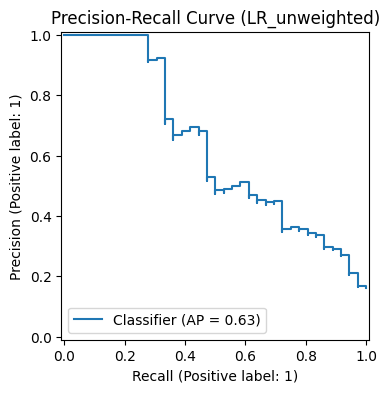

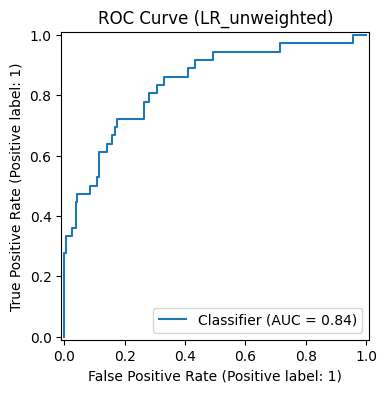


===== CONFUSION MATRIX =====
[[177   8]
 [ 20  16]]


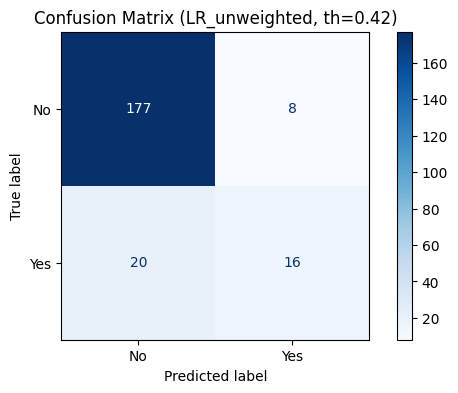

TN=177, FP=8, FN=20, TP=16

===== ERROR ANALYSIS =====
error_type
Correct    193
FN          20
FP           8
Name: count, dtype: int64

Top 10 False Positives:


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,y_true,y_score,y_pred,error_type
1168,24,Travel_Frequently,567,Research & Development,2,1,Technical Degree,1,Female,32,...,2,3,6,3,1,3,0,0.687886,1,FP
824,42,Travel_Rarely,188,Research & Development,29,3,Medical,2,Male,56,...,3,3,1,0,0,0,0,0.633945,1,FP
929,28,Travel_Frequently,193,Research & Development,2,3,Life Sciences,4,Male,52,...,2,3,2,2,2,2,0,0.597464,1,FP
496,21,Travel_Rarely,1343,Sales,22,1,Technical Degree,3,Male,49,...,2,3,3,2,1,2,0,0.580388,1,FP
841,24,Travel_Rarely,477,Research & Development,24,3,Medical,4,Male,49,...,2,3,4,3,1,2,0,0.555485,1,FP
747,38,Travel_Rarely,1035,Sales,3,4,Life Sciences,2,Male,42,...,1,3,1,0,0,0,0,0.530800,1,FP
397,25,Travel_Rarely,891,Sales,4,2,Life Sciences,2,Female,99,...,3,3,5,4,1,3,0,0.477528,1,FP
318,27,Travel_Rarely,1220,Research & Development,5,3,Life Sciences,3,Female,85,...,2,2,4,3,1,2,0,0.421048,1,FP



Top 10 False Negatives:


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,y_true,y_score,y_pred,error_type
1111,53,Travel_Rarely,607,Research & Development,2,5,Technical Degree,3,Female,78,...,4,3,33,7,1,9,1,0.002068,0,FN
45,41,Travel_Rarely,1360,Research & Development,12,3,Technical Degree,2,Female,49,...,0,3,22,15,15,8,1,0.017285,0,FN
700,58,Travel_Rarely,289,Research & Development,2,3,Technical Degree,4,Male,51,...,4,3,1,0,0,0,1,0.056053,0,FN
217,29,Travel_Rarely,992,Research & Development,1,3,Technical Degree,3,Male,85,...,1,2,6,2,1,5,1,0.070922,0,FN
562,33,Travel_Rarely,527,Research & Development,1,4,Other,4,Male,63,...,2,2,10,9,7,8,1,0.076456,0,FN
1204,48,Travel_Frequently,708,Sales,7,2,Medical,4,Female,95,...,3,3,9,7,7,7,1,0.098884,0,FN
789,44,Travel_Rarely,1376,Human Resources,1,2,Medical,2,Male,91,...,1,3,20,6,3,6,1,0.109536,0,FN
953,44,Travel_Rarely,935,Research & Development,3,3,Life Sciences,1,Male,89,...,4,4,3,2,1,2,1,0.113200,0,FN
24,34,Travel_Rarely,699,Research & Development,6,1,Medical,2,Male,83,...,2,3,4,2,1,3,1,0.128687,0,FN
985,31,Travel_Rarely,330,Research & Development,22,4,Medical,4,Male,98,...,3,2,10,2,6,7,1,0.129376,0,FN



Error analysis grouped by OverTime:


...


===== MODEL INTERPRETATION =====

Top positive coefficients (push toward Attrition=Yes):


,feature,coef,abs_coef
0,OverTime_Yes,1.771105,1.771105
4,JobRole_Laboratory Technician,0.790165,0.790165
9,JobRole_Sales Representative,0.546274,0.546274
10,YearsSinceLastPromotion,0.513954,0.513954
15,NumCompaniesWorked,0.453949,0.453949
20,BusinessTravel_Travel_Frequently,0.404950,0.404950
23,DistanceFromHome,0.381667,0.381667
25,YearsAtCompany,0.355814,0.355814
30,Gender_Male,0.255330,0.255330
31,EducationField_Human Resources,0.250712,0.250712



Top negative coefficients (push toward Attrition=No):


,feature,coef,abs_coef
1,BusinessTravel_Non-Travel,-1.332318,1.332318
2,JobRole_Research Director,-1.172536,1.172536
3,MaritalStatus_Divorced,-0.833371,0.833371
5,EducationField_Other,-0.767944,0.767944
6,Department_Research & Development,-0.730816,0.730816
7,MaritalStatus_Married,-0.629878,0.629878
8,EducationField_Medical,-0.573264,0.573264
11,JobRole_Healthcare Representative,-0.511007,0.511007
12,Department_Human Resources,-0.467969,0.467969
13,YearsInCurrentRole,-0.460252,0.460252



===== SAVING REPORT-READY FILES =====
Saved:
- split_artifacts.json
- oof_model_comparison.csv
- cross_validate_summary.csv
- oof_threshold_plan.csv
- test_threshold_comparison.csv
- final_test_metrics.csv
- test_error_analysis_full.csv
- feature_coefficients.csv


In [1]:
# ==============================================================
# IBM HR Attrition - End-to-End ML Notebook (Colab-ready)
# 目标：
# 1) 固定最终 test set
# 2) 仅在 train_val 内做 OOF 模型选择
# 3) 将“模型排序”和“阈值选择”彻底拆开
# 4) 输出报告可直接使用的表格、图、误差分析、特征解释
# 5) 数据集默认放在 /content 目录
# 6) 使用 drop='if_binary' 优化二元变量解释
# 7) 增加 cross_validate 均值±标准差表，增强模型比较的可 defend 性
# ==============================================================

# =========================
# 0. Imports & Config
# =========================
import os
import json
import warnings
import subprocess
import sys
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
)

from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
TEST_SIZE = 0.15
CV_SPLITS = 5

# 可选: "default_0.5", "best_f1", "recall_floor"
REPORT_THRESHOLD_POLICY = "best_f1"

# 只作为 business-oriented 对照，不再是唯一主线
RECALL_FLOOR = 0.60

# 如果环境能用就加入；不能用自动跳过
ENABLE_XGBOOST = True

plt.rcParams["figure.figsize"] = (7, 4)

# =========================
# 1. Data Load
# =========================
DATA_PATH_CANDIDATES = [
    "/content/WA_Fn-UseC_-HR-Employee-Attrition.csv",
    "WA_Fn-UseC_-HR-Employee-Attrition.csv",
]

DATA_PATH = None
for p in DATA_PATH_CANDIDATES:
    if os.path.exists(p):
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "没有找到数据文件。请把 WA_Fn-UseC_-HR-Employee-Attrition.csv 放到 /content/ 目录。"
    )

df_raw = pd.read_csv(DATA_PATH)
print(f"Loaded data from: {DATA_PATH}")
print("Raw shape:", df_raw.shape)

# =========================
# 2. Data Audit
# =========================
target_col = "Attrition"

constant_cols = [c for c in df_raw.columns if df_raw[c].nunique(dropna=False) <= 1]
id_like_cols = [c for c in df_raw.columns if df_raw[c].nunique(dropna=False) == len(df_raw)]
missing_total = int(df_raw.isna().sum().sum())
duplicate_rows = int(df_raw.duplicated().sum())

audit = {
    "shape": df_raw.shape,
    "target_col": target_col,
    "missing_total": missing_total,
    "duplicate_rows": duplicate_rows,
    "constant_cols": constant_cols,
    "id_like_cols": id_like_cols,
    "target_distribution_raw": df_raw[target_col].value_counts().to_dict(),
}

print("\n===== DATA AUDIT =====")
print(json.dumps(audit, indent=2, ensure_ascii=False, default=str))

# =========================
# 3. Minimal, High-Value EDA
# =========================
df_eda = df_raw.copy()
df_eda["AttritionFlag"] = df_eda["Attrition"].map({"No": 0, "Yes": 1})

print("\n===== BASIC TARGET STATS =====")
target_dist = df_eda["Attrition"].value_counts()
target_rate = df_eda["AttritionFlag"].mean()
print("Target distribution:")
print(target_dist)
print(f"Positive rate (Attrition=Yes): {target_rate:.4f}")

# 图1：目标分布
plt.figure()
target_dist.plot(kind="bar")
plt.title("Target Distribution (Attrition)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# 类别特征：只画最有用的两个
for cat_col in ["OverTime", "JobRole"]:
    if cat_col in df_eda.columns:
        rate = (
            df_eda.groupby(cat_col)["AttritionFlag"]
            .mean()
            .sort_values(ascending=False)
        )
        plt.figure(figsize=(8, 4))
        rate.plot(kind="bar")
        plt.title(f"Attrition Rate by {cat_col}")
        plt.ylabel("Attrition Rate")
        plt.xticks(rotation=45, ha="right")
        plt.show()
        print(f"\nAttrition rate by {cat_col}:")
        print(rate.round(4))

# 数值特征：只保留最有解释价值的两个
for num_col in ["MonthlyIncome", "Age"]:
    if num_col in df_eda.columns:
        plt.figure(figsize=(6, 4))
        df_eda.boxplot(column=num_col, by="Attrition")
        plt.title(f"{num_col} by Attrition")
        plt.suptitle("")
        plt.xlabel("Attrition")
        plt.ylabel(num_col)
        plt.show()

        grouped = df_eda.groupby("Attrition")[num_col].agg(["mean", "median"])
        print(f"\n{num_col} grouped summary:")
        print(grouped.round(2))

# =========================
# 4. Label + Feature Prep
# =========================
# 只删真正无信息 / 不适合建模的列
INVALID_COLS = ["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"]
drop_cols = sorted([c for c in INVALID_COLS if c in df_raw.columns])

print("\nDropping invalid / constant / ID-like columns:", drop_cols)

df = df_raw.drop(columns=drop_cols).copy()
df[target_col] = df[target_col].map({"No": 0, "Yes": 1}).astype(int)

X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

# 自动识别类别/数值列
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("\nCategorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

# 使用 drop='if_binary'，让二元变量只保留一列，解释更干净
try:
    ohe = OneHotEncoder(
        handle_unknown="ignore",
        drop="if_binary",
        sparse_output=False
    )
except TypeError:
    # 兼容旧版本 sklearn
    ohe = OneHotEncoder(
        handle_unknown="ignore",
        drop="if_binary",
        sparse=False
    )

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", ohe),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

# =========================
# 5. Fixed Hold-out Test Split
# =========================
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_SEED,
)

split_artifacts = {
    "random_seed": RANDOM_SEED,
    "test_size": TEST_SIZE,
    "train_val_index": X_train_val.index.tolist(),
    "test_index": X_test.index.tolist(),
    "train_val_positive_rate": float(y_train_val.mean()),
    "test_positive_rate": float(y_test.mean()),
}
with open("split_artifacts.json", "w", encoding="utf-8") as f:
    json.dump(split_artifacts, f, indent=2, ensure_ascii=False)

print("\n===== SPLIT INFO =====")
print("Train_val shape:", X_train_val.shape)
print("Test shape:", X_test.shape)
print(f"Train_val positive rate: {y_train_val.mean():.4f}")
print(f"Test positive rate: {y_test.mean():.4f}")
print("Saved split_artifacts.json")

# =========================
# 6. Candidate Models
# =========================
candidates: Dict[str, Pipeline] = {}

# 6.1 Dummy baseline
candidates["Dummy_prior"] = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", DummyClassifier(strategy="prior")),
    ]
)

# 6.2 Logistic Regression - unweighted
candidates["LR_unweighted"] = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000,
            solver="liblinear",
            random_state=RANDOM_SEED
        )),
    ]
)

# 6.3 Logistic Regression - balanced
candidates["LR_balanced"] = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000,
            solver="liblinear",
            class_weight="balanced",
            random_state=RANDOM_SEED
        )),
    ]
)

# 6.4 Random Forest - 一个稳健版本即可
candidates["RF_balanced"] = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=3,
            class_weight="balanced_subsample",
            random_state=RANDOM_SEED,
            n_jobs=-1
        )),
    ]
)

# 6.5 XGBoost - 如果环境可用则加入
xgb_available = False
if ENABLE_XGBOOST:
    try:
        from xgboost import XGBClassifier
        xgb_available = True
    except Exception:
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
            from xgboost import XGBClassifier
            xgb_available = True
        except Exception:
            xgb_available = False

if xgb_available:
    neg = int((y_train_val == 0).sum())
    pos = int((y_train_val == 1).sum())
    scale_pos_weight = neg / max(pos, 1)
    print(f"\n[XGBoost] scale_pos_weight = {scale_pos_weight:.4f}")

    candidates["XGB_scale_pos_weight"] = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                reg_lambda=1.0,
                scale_pos_weight=scale_pos_weight,
                eval_metric="logloss",
                random_state=RANDOM_SEED,
                n_jobs=-1
            )),
        ]
    )
else:
    print("\n[XGBoost] 不可用，自动跳过。")

print("\nCandidate models:", list(candidates.keys()))

# =========================
# 7. Helpers
# =========================
cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_SEED)

def metrics_from_scores(y_true: pd.Series, y_score: np.ndarray, threshold: float = 0.5) -> Dict[str, float]:
    y_pred = (y_score >= threshold).astype(int)
    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_score)),
        "pr_auc": float(average_precision_score(y_true, y_score)),
    }

def choose_best_f1_threshold(y_true: pd.Series, y_score: np.ndarray) -> Tuple[float, Dict[str, float]]:
    thresholds = np.linspace(0.01, 0.99, 99)
    rows = []
    for th in thresholds:
        m = metrics_from_scores(y_true, y_score, threshold=th)
        rows.append(m)
    df_th = pd.DataFrame(rows).sort_values(
        by=["f1", "precision", "recall"],
        ascending=[False, False, False]
    ).reset_index(drop=True)
    best_row = df_th.iloc[0].to_dict()
    return float(best_row["threshold"]), best_row

def choose_recall_floor_threshold(
    y_true: pd.Series,
    y_score: np.ndarray,
    recall_floor: float = 0.60
) -> Tuple[float, Dict[str, float]]:
    thresholds = np.linspace(0.01, 0.99, 99)
    rows = []
    for th in thresholds:
        m = metrics_from_scores(y_true, y_score, threshold=th)
        rows.append(m)
    df_th = pd.DataFrame(rows)

    feasible = df_th[df_th["recall"] >= recall_floor].copy()
    if len(feasible) == 0:
        fallback = df_th.sort_values(
            by=["recall", "f1", "precision"],
            ascending=[False, False, False]
        ).reset_index(drop=True)
        best_row = fallback.iloc[0].to_dict()
        return float(best_row["threshold"]), best_row

    feasible = feasible.sort_values(
        by=["f1", "precision", "accuracy"],
        ascending=[False, False, False]
    ).reset_index(drop=True)
    best_row = feasible.iloc[0].to_dict()
    return float(best_row["threshold"]), best_row

def safe_get_feature_names(preprocessor_fitted: ColumnTransformer) -> List[str]:
    feature_names = []
    for name, transformer, cols in preprocessor_fitted.transformers_:
        if name == "remainder":
            continue

        if hasattr(transformer, "named_steps"):
            last_step = list(transformer.named_steps.values())[-1]
            if hasattr(last_step, "get_feature_names_out"):
                try:
                    out = last_step.get_feature_names_out(cols)
                    feature_names.extend(out.tolist())
                except Exception:
                    feature_names.extend(list(cols))
            else:
                feature_names.extend(list(cols))
        else:
            if hasattr(transformer, "get_feature_names_out"):
                try:
                    out = transformer.get_feature_names_out(cols)
                    feature_names.extend(out.tolist())
                except Exception:
                    feature_names.extend(list(cols))
            else:
                feature_names.extend(list(cols))
    return feature_names

# =========================
# 8. OOF Model Comparison
# =========================
oof_rows = []
oof_scores_by_model = {}

print("\n===== OOF MODEL COMPARISON =====")
for model_name, pipe in candidates.items():
    print(f"\n[OOF] Evaluating: {model_name}")
    oof_proba = cross_val_predict(
        pipe,
        X_train_val,
        y_train_val,
        cv=cv,
        method="predict_proba",
        n_jobs=None
    )[:, 1]

    oof_scores_by_model[model_name] = oof_proba

    # 模型排序主看 threshold-independent 指标，0.5 这里只是辅助展示
    row = metrics_from_scores(y_train_val, oof_proba, threshold=0.5)
    row["model"] = model_name
    oof_rows.append(row)

oof_results = pd.DataFrame(oof_rows)[[
    "model", "pr_auc", "roc_auc", "f1", "recall", "precision",
    "accuracy", "balanced_accuracy", "threshold"
]].sort_values(
    by=["pr_auc", "roc_auc", "f1"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("\n===== OOF RESULTS (MODEL RANKING) =====")
display(oof_results)

best_model_name = oof_results.iloc[0]["model"]
best_model = candidates[best_model_name]
best_oof_scores = oof_scores_by_model[best_model_name]

print(f"\nSelected best model by OOF ranking: {best_model_name}")

# =========================
# 8B. Cross-Validate Summary (mean ± std)
# =========================
print("\n===== CROSS-VALIDATE SUMMARY (MEAN ± STD) =====")

cv_scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "balanced_accuracy": "balanced_accuracy",
    "accuracy": "accuracy",
}

cv_summary_rows = []

for model_name, pipe in candidates.items():
    print(f"[CV] Running cross_validate for: {model_name}")

    cv_scores = cross_validate(
        pipe,
        X_train_val,
        y_train_val,
        cv=cv,
        scoring=cv_scoring,
        return_train_score=False,
        n_jobs=None
    )

    row = {"model": model_name}
    for metric_name in cv_scoring.keys():
        scores = cv_scores[f"test_{metric_name}"]
        row[f"{metric_name}_mean"] = float(np.mean(scores))
        row[f"{metric_name}_std"] = float(np.std(scores, ddof=0))
        row[f"{metric_name}_mean_std"] = f"{np.mean(scores):.4f} ± {np.std(scores, ddof=0):.4f}"

    cv_summary_rows.append(row)

cv_summary = pd.DataFrame(cv_summary_rows).sort_values(
    by=["pr_auc_mean", "roc_auc_mean", "f1_mean"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("\n===== CROSS-VALIDATE SUMMARY TABLE =====")
display(
    cv_summary[
        [
            "model",
            "pr_auc_mean_std",
            "roc_auc_mean_std",
            "f1_mean_std",
            "recall_mean_std",
            "precision_mean_std",
            "balanced_accuracy_mean_std",
            "accuracy_mean_std",
        ]
    ]
)

# =========================
# 9. Threshold Selection
# =========================
print("\n===== THRESHOLD SELECTION (OOF OF SELECTED MODEL ONLY) =====")

default_th = 0.50
best_f1_th, best_f1_oof_row = choose_best_f1_threshold(y_train_val, best_oof_scores)
recall_floor_th, recall_floor_oof_row = choose_recall_floor_threshold(
    y_train_val, best_oof_scores, recall_floor=RECALL_FLOOR
)

threshold_plan = pd.DataFrame([
    {"policy": "default_0.50", **metrics_from_scores(y_train_val, best_oof_scores, default_th)},
    {"policy": "best_f1", **best_f1_oof_row},
    {"policy": f"recall_floor_{RECALL_FLOOR:.2f}", **recall_floor_oof_row},
])

display(threshold_plan)

if REPORT_THRESHOLD_POLICY == "default_0.5":
    report_threshold = default_th
elif REPORT_THRESHOLD_POLICY == "best_f1":
    report_threshold = best_f1_th
elif REPORT_THRESHOLD_POLICY == "recall_floor":
    report_threshold = recall_floor_th
else:
    raise ValueError("Invalid REPORT_THRESHOLD_POLICY")

print(f"\nReport-friendly threshold policy: {REPORT_THRESHOLD_POLICY}")
print(f"Chosen report threshold: {report_threshold:.4f}")

# =========================
# 10. Final Fit on train_val
# =========================
print("\n===== FINAL FIT ON TRAIN_VAL =====")
best_model.fit(X_train_val, y_train_val)
test_proba = best_model.predict_proba(X_test)[:, 1]

# test 阈值对照表
test_threshold_table = pd.DataFrame([
    {"policy": "default_0.50", **metrics_from_scores(y_test, test_proba, default_th)},
    {"policy": "best_f1", **metrics_from_scores(y_test, test_proba, best_f1_th)},
    {"policy": f"recall_floor_{RECALL_FLOOR:.2f}", **metrics_from_scores(y_test, test_proba, recall_floor_th)},
]).sort_values(by=["policy"]).reset_index(drop=True)

print("\n===== TEST THRESHOLD COMPARISON =====")
display(test_threshold_table)

# 最终主结果（报告默认）
final_test_metrics = metrics_from_scores(y_test, test_proba, report_threshold)
print("\n===== FINAL TEST METRICS (REPORT VERSION) =====")
print(json.dumps(final_test_metrics, indent=2, ensure_ascii=False))

# =========================
# 11. PR / ROC Curves
# =========================
print("\n===== TEST CURVES =====")
PrecisionRecallDisplay.from_predictions(y_test, test_proba)
plt.title(f"Precision-Recall Curve ({best_model_name})")
plt.show()

RocCurveDisplay.from_predictions(y_test, test_proba)
plt.title(f"ROC Curve ({best_model_name})")
plt.show()

# =========================
# 12. Confusion Matrix
# =========================
final_test_pred = (test_proba >= report_threshold).astype(int)
cm = confusion_matrix(y_test, final_test_pred)

print("\n===== CONFUSION MATRIX =====")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix ({best_model_name}, th={report_threshold:.2f})")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# =========================
# 13. Error Analysis
# =========================
print("\n===== ERROR ANALYSIS =====")
error_df = X_test.copy()
error_df["y_true"] = y_test.values
error_df["y_score"] = test_proba
error_df["y_pred"] = final_test_pred
error_df["error_type"] = np.where(
    error_df["y_true"] == error_df["y_pred"],
    "Correct",
    np.where((error_df["y_true"] == 1) & (error_df["y_pred"] == 0), "FN", "FP")
)

print(error_df["error_type"].value_counts())

# 最值得看的误判：高分 FP、低分 FN
top_fp = error_df[error_df["error_type"] == "FP"].sort_values("y_score", ascending=False).head(10)
top_fn = error_df[error_df["error_type"] == "FN"].sort_values("y_score", ascending=True).head(10)

print("\nTop 10 False Positives:")
display(top_fp)

print("\nTop 10 False Negatives:")
display(top_fn)

# 按误差类型看几个关键字段
for col in ["OverTime", "JobRole", "MonthlyIncome", "Age"]:
    if col in error_df.columns:
        print(f"\nError analysis grouped by {col}:")
        try:
            summary = error_df.groupby("error_type")[col].value_counts(normalize=True).rename("ratio").reset_index()
            display(summary.head(20))
        except Exception:
            summary = error_df.groupby("error_type")[col].agg(["mean", "median", "count"])
            display(summary)

# =========================
# 14. Model Interpretation
# =========================
print("\n===== MODEL INTERPRETATION =====")

fitted_preprocessor = best_model.named_steps["preprocess"]
feature_names = safe_get_feature_names(fitted_preprocessor)

final_estimator = best_model.named_steps["model"]

if isinstance(final_estimator, LogisticRegression):
    coef = final_estimator.coef_[0]
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coef": coef,
        "abs_coef": np.abs(coef),
    }).sort_values("abs_coef", ascending=False).reset_index(drop=True)

    print("\nTop positive coefficients (push toward Attrition=Yes):")
    display(coef_df.sort_values("coef", ascending=False).head(15))

    print("\nTop negative coefficients (push toward Attrition=No):")
    display(coef_df.sort_values("coef", ascending=True).head(15))

elif hasattr(final_estimator, "feature_importances_"):
    imp = final_estimator.feature_importances_
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": imp
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    print("\nTop feature importances:")
    display(imp_df.head(20))

else:
    print("Current best model does not support direct coefficient/importance interpretation.")

# =========================
# 15. Save Report-Ready Outputs
# =========================
print("\n===== SAVING REPORT-READY FILES =====")

oof_results.to_csv("oof_model_comparison.csv", index=False)
cv_summary.to_csv("cross_validate_summary.csv", index=False)
threshold_plan.to_csv("oof_threshold_plan.csv", index=False)
test_threshold_table.to_csv("test_threshold_comparison.csv", index=False)

pd.DataFrame([{
    "best_model": best_model_name,
    "report_threshold_policy": REPORT_THRESHOLD_POLICY,
    "report_threshold_value": report_threshold,
    **final_test_metrics
}]).to_csv("final_test_metrics.csv", index=False)

error_df.to_csv("test_error_analysis_full.csv", index=False)

if isinstance(final_estimator, LogisticRegression):
    coef_df.to_csv("feature_coefficients.csv", index=False)
elif hasattr(final_estimator, "feature_importances_"):
    imp_df.to_csv("feature_importances.csv", index=False)

print("Saved:")
print("- split_artifacts.json")
print("- oof_model_comparison.csv")
print("- cross_validate_summary.csv")
print("- oof_threshold_plan.csv")
print("- test_threshold_comparison.csv")
print("- final_test_metrics.csv")
print("- test_error_analysis_full.csv")
if isinstance(final_estimator, LogisticRegression):
    print("- feature_coefficients.csv")
elif hasattr(final_estimator, "feature_importances_"):
    print("- feature_importances.csv")

## 2. Report / Presentation Visualizations

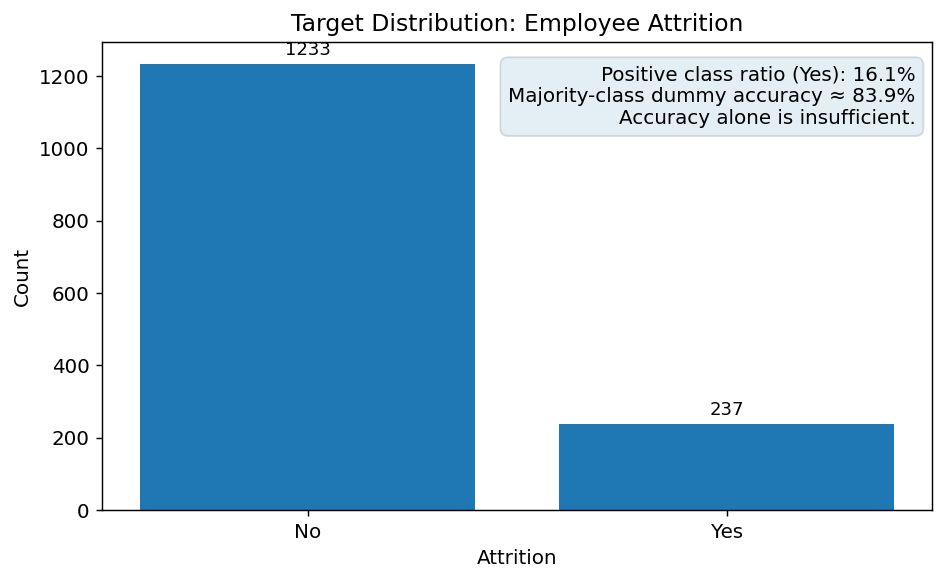

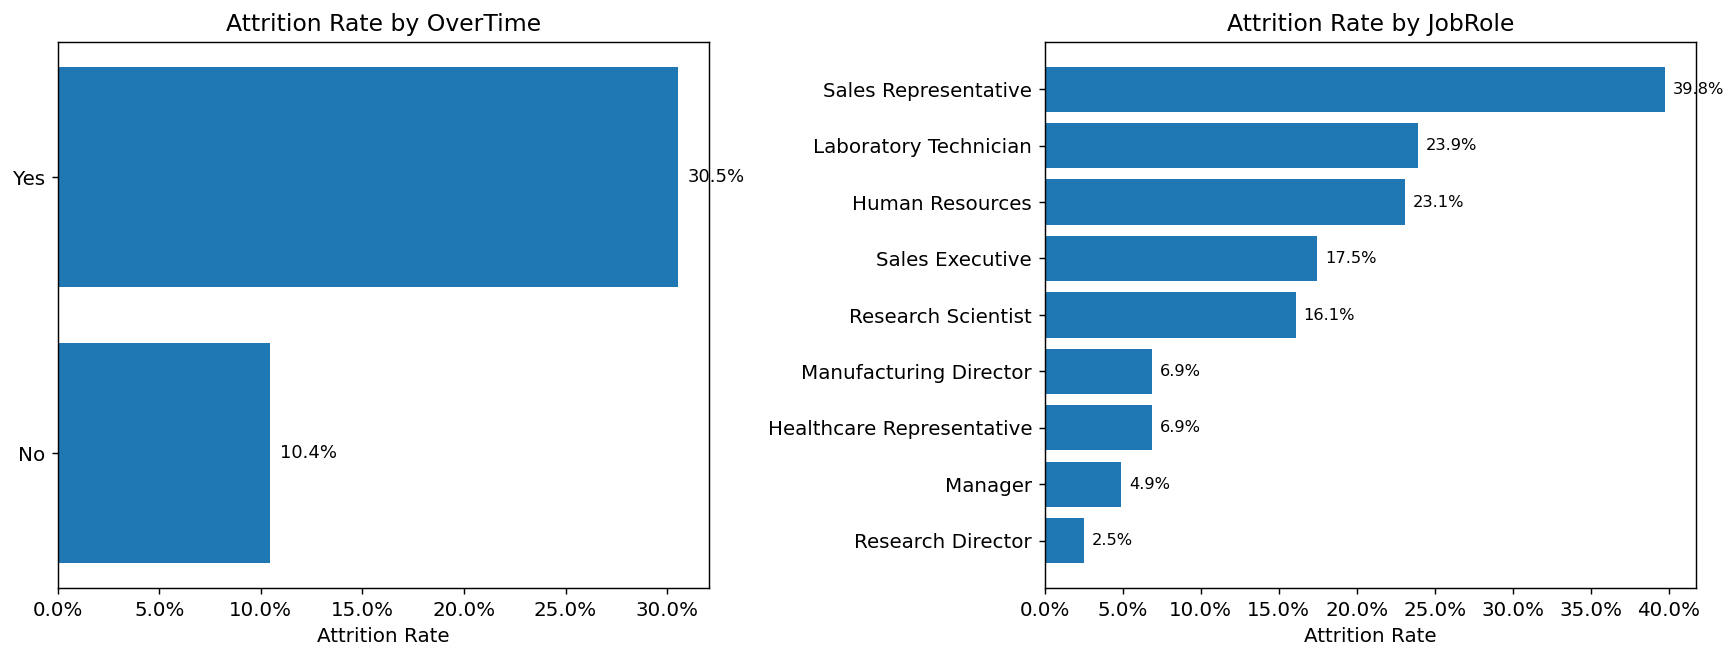

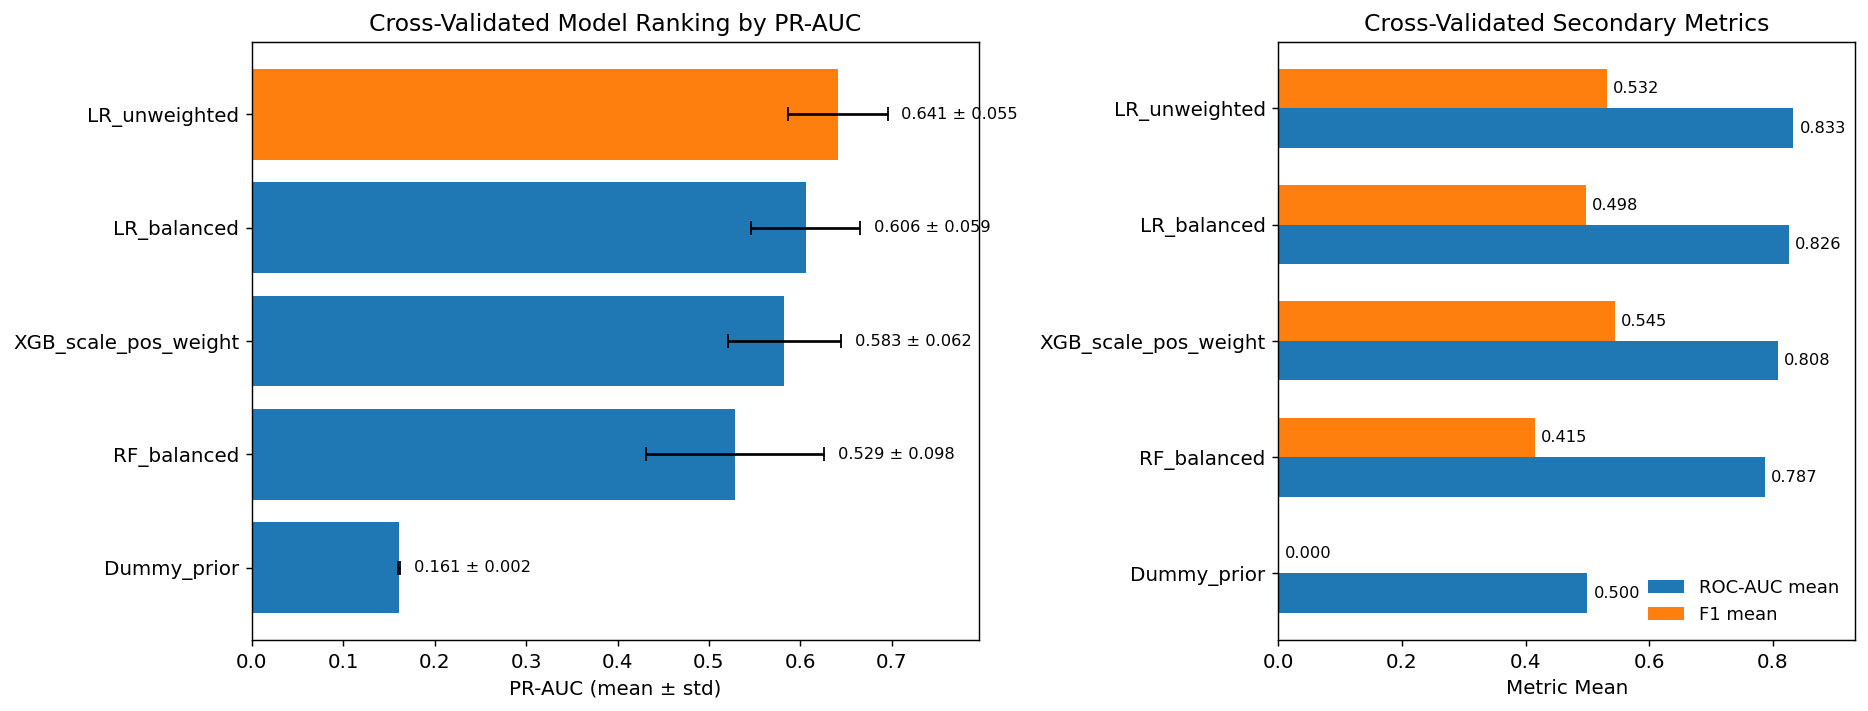

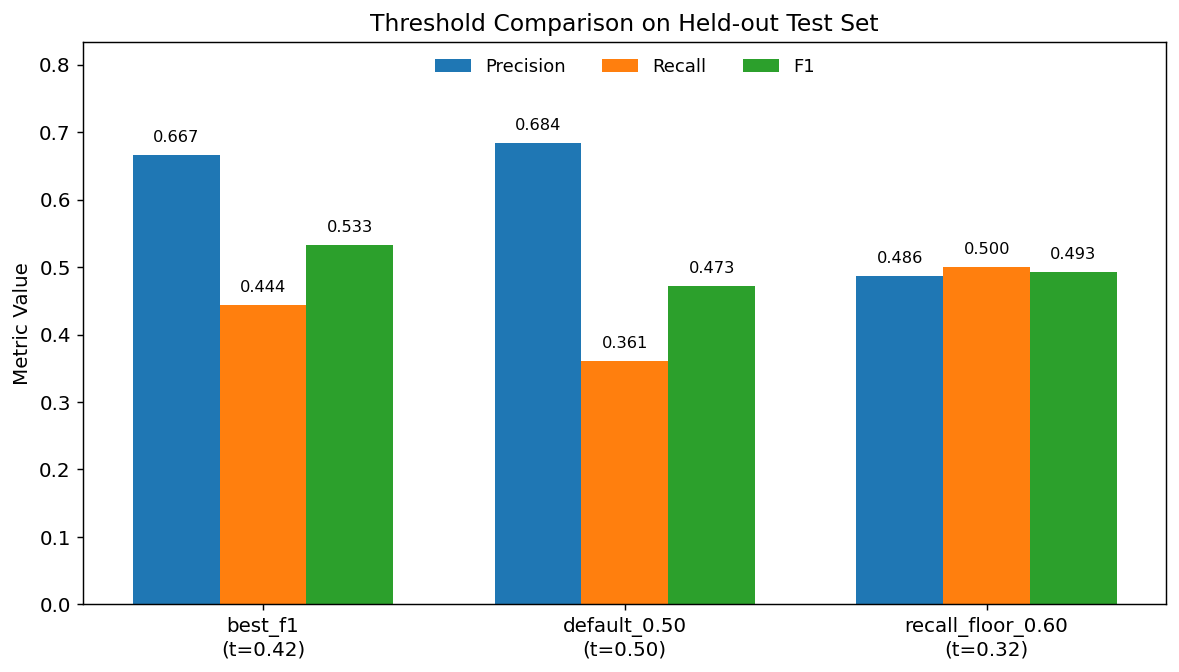

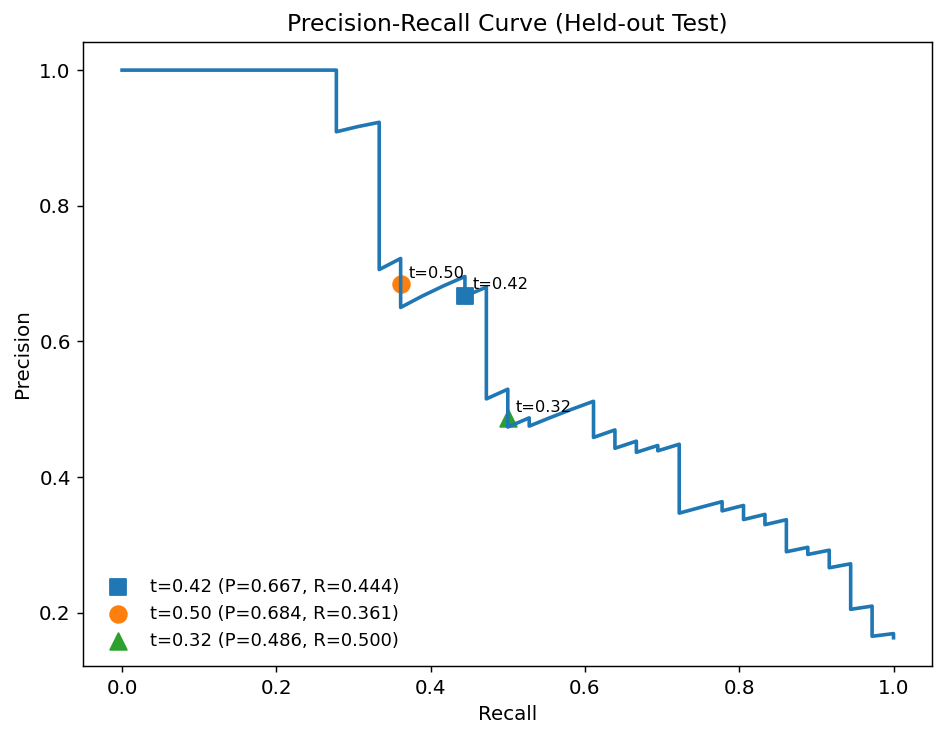

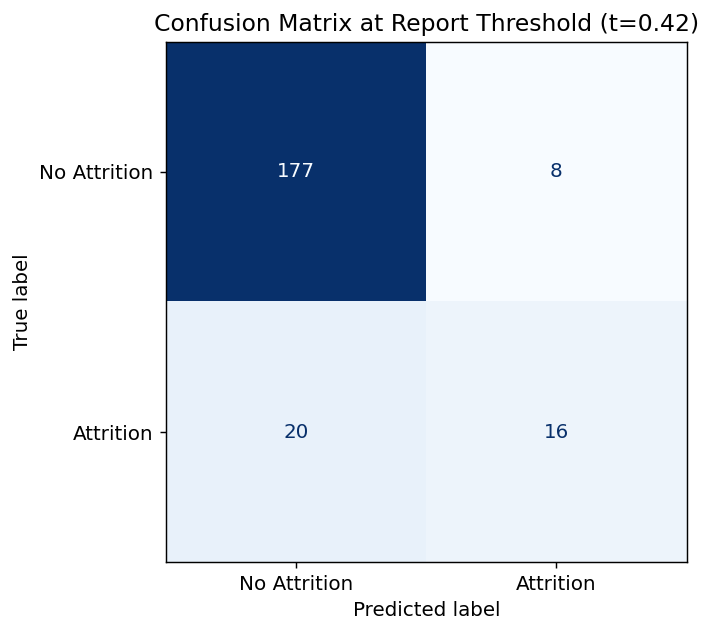

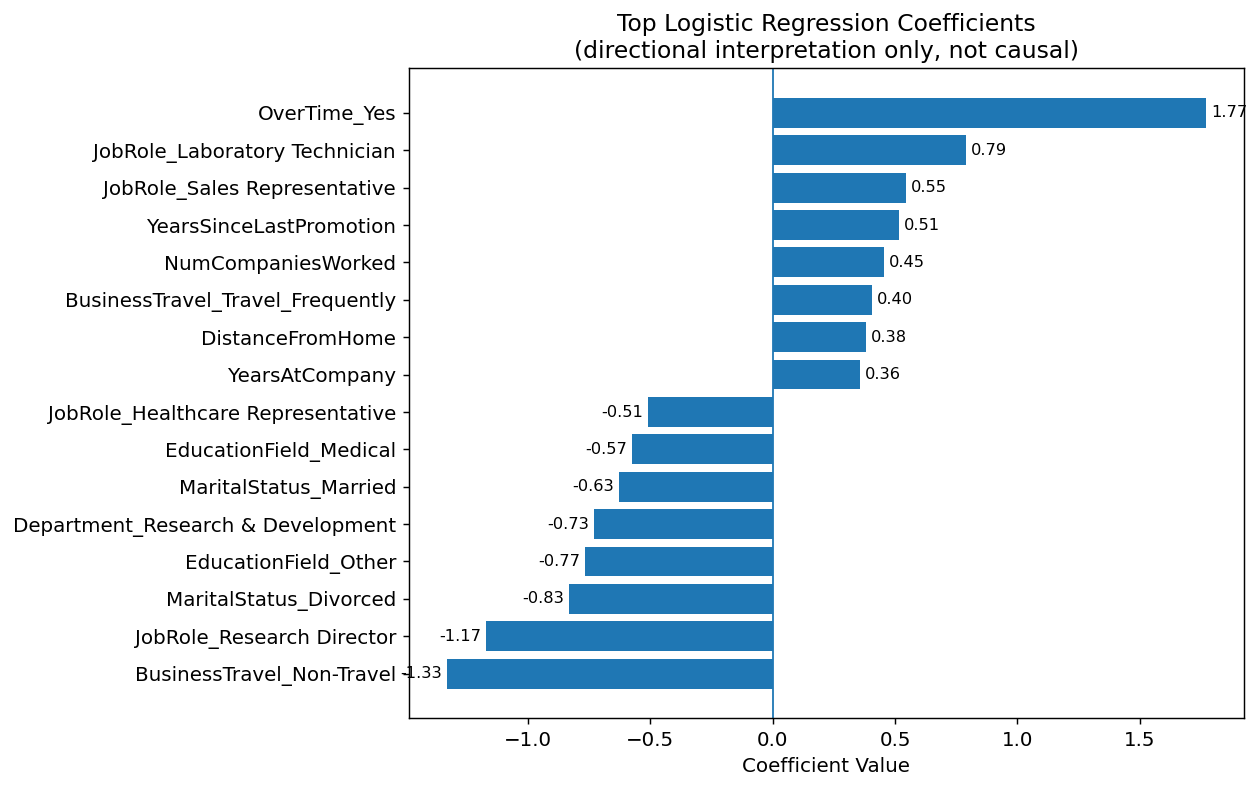

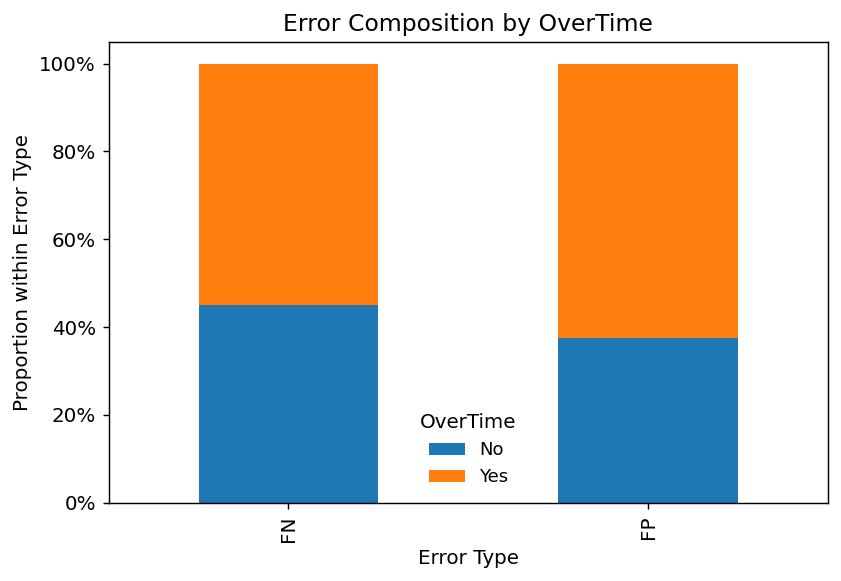

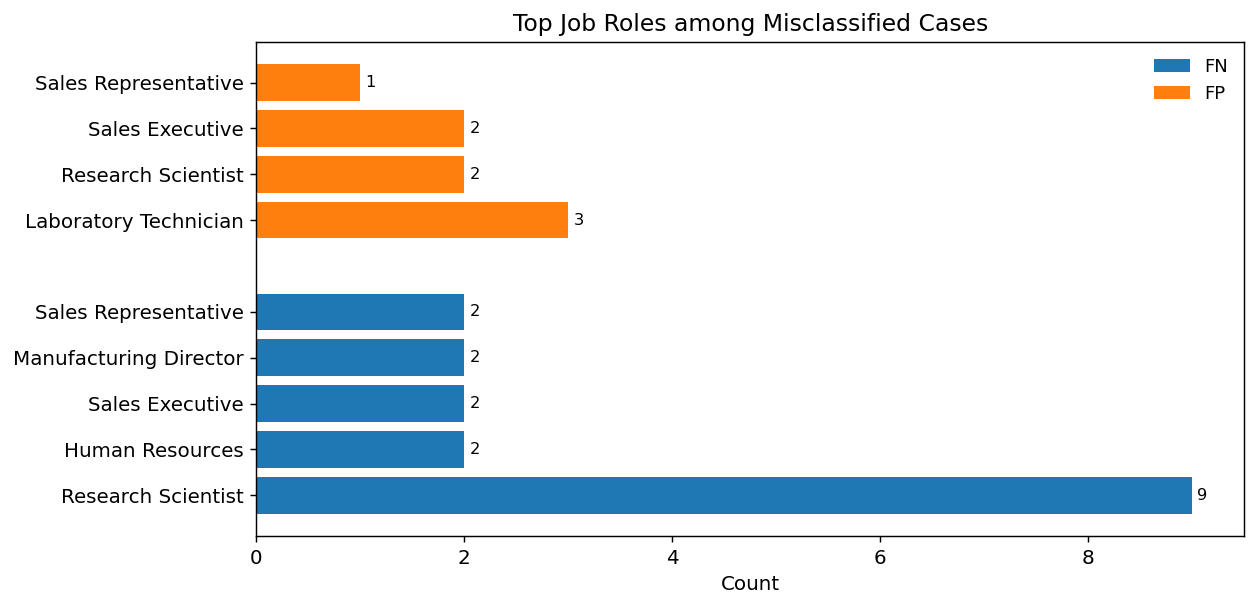


可视化增强完成。图片已保存到：report_figures/
建议优先用于报告/PPT的文件：
01_target_distribution.png
02_attrition_rate_overtime_jobrole.png
03_cv_model_comparison.png 或 03_oof_model_comparison.png
04_threshold_comparison_metrics.png
05_pr_curve_with_threshold_points.png
06_confusion_matrix_presentation.png
07_lr_coefficients_directional.png
08_error_analysis_overtime.png / 09_error_analysis_jobrole.png


In [2]:
# ==============================================================
# 可视化增强代码（直接接在现有 notebook 后面运行）
# 目的：只补图，不重复主流程，不重新训练模型
# 适用：报告截图 / Presentation 页面
# 适配：
# 1) drop='if_binary' 后的 LR 系数解释
# 2) 新增的 cross_validate mean ± std 结果
# ==============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from sklearn.metrics import precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay

# -----------------------------
# 0. 保护性检查与基础设置
# -----------------------------
required_any = {
    "df_raw or df_eda": ("df_raw" in globals()) or ("df_eda" in globals()),
    "oof_results": "oof_results" in globals(),
    "test_threshold_table": "test_threshold_table" in globals(),
    "y_test": "y_test" in globals(),
    "test_proba": "test_proba" in globals(),
    "report_threshold": "report_threshold" in globals(),
}

missing = [k for k, v in required_any.items() if not v]
if missing:
    raise ValueError(f"以下关键变量不存在，请先运行主流程：{missing}")

plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 10

# 尽量复用现有变量
df_plot = df_eda.copy() if "df_eda" in globals() else df_raw.copy()

# 若 df_plot 中没有 AttritionFlag，则补上
if "AttritionFlag" not in df_plot.columns and "Attrition" in df_plot.columns:
    if df_plot["Attrition"].dtype == object:
        df_plot["AttritionFlag"] = df_plot["Attrition"].map({"No": 0, "Yes": 1})
    else:
        df_plot["AttritionFlag"] = df_plot["Attrition"]

# 阈值表保护
test_table = test_threshold_table.copy()
if "policy" not in test_table.columns:
    test_table["policy"] = [f"threshold_{t:.2f}" for t in test_table["threshold"]]

# cross_validate summary 保护：优先使用内存变量，其次尝试读取 csv
cv_plot_df = None
if "cv_summary" in globals():
    cv_plot_df = cv_summary.copy()
elif os.path.exists("cross_validate_summary.csv"):
    cv_plot_df = pd.read_csv("cross_validate_summary.csv")

# 建立输出目录
os.makedirs("report_figures", exist_ok=True)

def save_current_fig(filename: str):
    plt.tight_layout()
    plt.savefig(os.path.join("report_figures", filename), bbox_inches="tight")
    plt.show()
    plt.close()

def format_percent_axis(ax, axis="x"):
    if axis == "x":
        ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    else:
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))

# ------------------------------------------------------
# 1) 目标分布图：用于第一页/数据介绍页，说明类别不平衡
# ------------------------------------------------------
if "Attrition" in df_plot.columns:
    target_counts = df_plot["Attrition"].value_counts()
    yes_count = int(target_counts.get("Yes", 0))
    no_count = int(target_counts.get("No", 0))
    total = yes_count + no_count
    pos_rate = yes_count / total if total > 0 else np.nan
    dummy_acc = no_count / total if total > 0 else np.nan

    fig, ax = plt.subplots(figsize=(7.4, 4.6))
    bars = ax.bar(["No", "Yes"], [no_count, yes_count])

    ax.set_title("Target Distribution: Employee Attrition")
    ax.set_ylabel("Count")
    ax.set_xlabel("Attrition")

    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + total * 0.01,
            f"{int(h)}",
            ha="center",
            va="bottom",
            fontsize=10
        )

    note = (
        f"Positive class ratio (Yes): {pos_rate:.1%}\n"
        f"Majority-class dummy accuracy ≈ {dummy_acc:.1%}\n"
        f"Accuracy alone is insufficient."
    )
    ax.text(
        0.98, 0.95, note,
        transform=ax.transAxes,
        va="top", ha="right",
        bbox=dict(boxstyle="round,pad=0.4", alpha=0.12)
    )

    save_current_fig("01_target_distribution.png")

# -----------------------------------------------------------------------
# 2) OverTime / JobRole 的 attrition rate：用于 EDA 页，支撑“确实有可学信号”
# -----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

# OverTime
if "OverTime" in df_plot.columns and "AttritionFlag" in df_plot.columns:
    overtime_rate = (
        df_plot.groupby("OverTime")["AttritionFlag"]
        .mean()
        .sort_values(ascending=True)
    )
    axes[0].barh(overtime_rate.index.astype(str), overtime_rate.values)
    axes[0].set_title("Attrition Rate by OverTime")
    axes[0].set_xlabel("Attrition Rate")
    format_percent_axis(axes[0], axis="x")
    for i, v in enumerate(overtime_rate.values):
        axes[0].text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=10)
else:
    axes[0].set_visible(False)

# JobRole
if "JobRole" in df_plot.columns and "AttritionFlag" in df_plot.columns:
    jobrole_rate = (
        df_plot.groupby("JobRole")["AttritionFlag"]
        .mean()
        .sort_values(ascending=True)
    )
    axes[1].barh(jobrole_rate.index.astype(str), jobrole_rate.values)
    axes[1].set_title("Attrition Rate by JobRole")
    axes[1].set_xlabel("Attrition Rate")
    format_percent_axis(axes[1], axis="x")
    for i, v in enumerate(jobrole_rate.values):
        axes[1].text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=9)
else:
    axes[1].set_visible(False)

save_current_fig("02_attrition_rate_overtime_jobrole.png")

# ---------------------------------------------------------------------
# 3) Model comparison plots (final version)
# Fixes:
# 1) Move PR-AUC labels outside the error bars so they do not overlap
# 2) Replace the secondary-metrics scatter plot with grouped horizontal bar charts
# ---------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

if cv_plot_df is not None:
    plot_df = cv_plot_df.copy().sort_values("pr_auc_mean", ascending=True).reset_index(drop=True)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(14.5, 5.6),
        gridspec_kw={"width_ratios": [1.45, 1.15]}
    )

    # =========================================================
    # Left chart: Cross-validated PR-AUC ranking (mean ± std)
    # =========================================================
    colors = ["C0" if m != "LR_unweighted" else "C1" for m in plot_df["model"]]

    axes[0].barh(
        plot_df["model"],
        plot_df["pr_auc_mean"],
        xerr=plot_df["pr_auc_std"],
        color=colors,
        capsize=4
    )
    axes[0].set_title("Cross-Validated Model Ranking by PR-AUC")
    axes[0].set_xlabel("PR-AUC (mean ± std)")

    # Put text outside the error bar
    label_pad = 0.015
    xmax_left = (plot_df["pr_auc_mean"] + plot_df["pr_auc_std"]).max() + 0.10
    axes[0].set_xlim(0, xmax_left)

    for i, (mean_v, std_v) in enumerate(zip(plot_df["pr_auc_mean"], plot_df["pr_auc_std"])):
        x_text = mean_v + std_v + label_pad
        axes[0].text(
            x_text,
            i,
            f"{mean_v:.3f} ± {std_v:.3f}",
            va="center",
            ha="left",
            fontsize=9,
            clip_on=False
        )

    # =========================================================
    # Right chart: Cross-validated secondary metrics (bar chart)
    # =========================================================
    y_pos = np.arange(len(plot_df))
    bar_h = 0.34

    axes[1].barh(
        y_pos - bar_h / 2,
        plot_df["roc_auc_mean"],
        height=bar_h,
        label="ROC-AUC mean"
    )
    axes[1].barh(
        y_pos + bar_h / 2,
        plot_df["f1_mean"],
        height=bar_h,
        label="F1 mean"
    )

    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(plot_df["model"])
    axes[1].set_title("Cross-Validated Secondary Metrics")
    axes[1].set_xlabel("Metric Mean")
    axes[1].legend(frameon=False, loc="lower right")

    xmax_right = max(plot_df["roc_auc_mean"].max(), plot_df["f1_mean"].max()) + 0.10
    axes[1].set_xlim(0, xmax_right)

    for i, (rocv, f1v) in enumerate(zip(plot_df["roc_auc_mean"], plot_df["f1_mean"])):
        axes[1].text(rocv + 0.01, y_pos[i] - bar_h / 2, f"{rocv:.3f}", va="center", ha="left", fontsize=9)
        axes[1].text(f1v + 0.01, y_pos[i] + bar_h / 2, f"{f1v:.3f}", va="center", ha="left", fontsize=9)

    plt.tight_layout()
    save_current_fig("03_cv_model_comparison.png")
    plt.show()

elif "oof_results" in globals():
    plot_df = oof_results.copy().sort_values("pr_auc", ascending=True).reset_index(drop=True)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(14.5, 5.6),
        gridspec_kw={"width_ratios": [1.45, 1.15]}
    )

    # =========================================================
    # Left chart: OOF PR-AUC ranking
    # =========================================================
    colors = ["C0" if m != "LR_unweighted" else "C1" for m in plot_df["model"]]

    axes[0].barh(
        plot_df["model"],
        plot_df["pr_auc"],
        color=colors
    )
    axes[0].set_title("OOF Model Ranking by PR-AUC")
    axes[0].set_xlabel("PR-AUC (Average Precision)")

    xmax_left = plot_df["pr_auc"].max() + 0.12
    axes[0].set_xlim(0, xmax_left)

    for i, v in enumerate(plot_df["pr_auc"]):
        axes[0].text(
            v + 0.015,
            i,
            f"{v:.3f}",
            va="center",
            ha="left",
            fontsize=9,
            clip_on=False
        )

    # =========================================================
    # Right chart: OOF secondary metrics (bar chart)
    # =========================================================
    y_pos = np.arange(len(plot_df))
    bar_h = 0.34

    axes[1].barh(
        y_pos - bar_h / 2,
        plot_df["roc_auc"],
        height=bar_h,
        label="ROC-AUC"
    )
    axes[1].barh(
        y_pos + bar_h / 2,
        plot_df["f1"],
        height=bar_h,
        label="F1@0.50"
    )

    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(plot_df["model"])
    axes[1].set_title("OOF Secondary Metrics")
    axes[1].set_xlabel("Metric Value")
    axes[1].legend(frameon=False, loc="lower right")

    xmax_right = max(plot_df["roc_auc"].max(), plot_df["f1"].max()) + 0.10
    axes[1].set_xlim(0, xmax_right)

    for i, (rocv, f1v) in enumerate(zip(plot_df["roc_auc"], plot_df["f1"])):
        axes[1].text(rocv + 0.01, y_pos[i] - bar_h / 2, f"{rocv:.3f}", va="center", ha="left", fontsize=9)
        axes[1].text(f1v + 0.01, y_pos[i] + bar_h / 2, f"{f1v:.3f}", va="center", ha="left", fontsize=9)

    plt.tight_layout()
    save_current_fig("03_oof_model_comparison.png")
    plt.show()

else:
    print("No cross-validation or OOF results found for plotting.")

# --------------------------------------------------------------------------------
# 4) Threshold 对比图：主看 Precision / Recall / F1，不把 accuracy 放主图
# --------------------------------------------------------------------------------
if "test_threshold_table" in globals():
    metric_cols = ["precision", "recall", "f1"]

    threshold_labels = []
    for _, row in test_table.iterrows():
        th = float(row["threshold"])
        threshold_labels.append(f"{row['policy']}\n(t={th:.2f})")

    x = np.arange(len(test_table))
    width = 0.24

    fig, ax = plt.subplots(figsize=(9.2, 5.3))
    ax.bar(x - width, test_table["precision"], width, label="Precision")
    ax.bar(x,         test_table["recall"],    width, label="Recall")
    ax.bar(x + width, test_table["f1"],        width, label="F1")

    ax.set_title("Threshold Comparison on Held-out Test Set")
    ax.set_ylabel("Metric Value")
    ax.set_xticks(x)
    ax.set_xticklabels(threshold_labels)
    ax.legend(frameon=False, ncol=3, loc="upper center")
    ax.set_ylim(0, max(test_table[metric_cols].max()) + 0.15)

    for xpos, col, offset in zip([x - width, x, x + width], metric_cols, [-width, 0, width]):
        for i, v in enumerate(test_table[col]):
            ax.text(i + offset, v + 0.015, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

    save_current_fig("04_threshold_comparison_metrics.png")

# --------------------------------------------------------------------------------------------------------
# 5) PR Curve + 三个 threshold operating points：说明 0.50 / 0.41 / 0.32 的 trade-off
# --------------------------------------------------------------------------------------------------------
if ("y_test" in globals()) and ("test_proba" in globals()) and ("test_threshold_table" in globals()):
    y_true_arr = np.asarray(y_test)
    y_score_arr = np.asarray(test_proba)

    precisions, recalls, thresholds = precision_recall_curve(y_true_arr, y_score_arr)

    fig, ax = plt.subplots(figsize=(7.4, 5.8))
    ax.plot(recalls, precisions, linewidth=2)
    ax.set_title("Precision-Recall Curve (Held-out Test)")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")

    # 使用 policy 名字而不是浮点数硬匹配，更稳
    policy_styles = {
        "default_0.50": {"marker": "o", "short": "0.50"},
        "best_f1": {"marker": "s", "short": "0.41"},
        "recall_floor_0.60": {"marker": "^", "short": "0.32"},
    }

    for _, row in test_table.iterrows():
        policy = str(row["policy"])
        if policy in policy_styles:
            style = policy_styles[policy]
            ax.scatter(
                row["recall"],
                row["precision"],
                s=85,
                marker=style["marker"],
                label=f"t={float(row['threshold']):.2f} (P={row['precision']:.3f}, R={row['recall']:.3f})"
            )
            ax.text(
                row["recall"] + 0.01,
                row["precision"] + 0.01,
                f"t={float(row['threshold']):.2f}",
                fontsize=9
            )

    ax.legend(frameon=False, loc="lower left")
    save_current_fig("05_pr_curve_with_threshold_points.png")

# ---------------------------------------------------------------
# 6) 美化版 confusion matrix：适合直接放 PPT
# ---------------------------------------------------------------
if ("y_test" in globals()) and ("test_proba" in globals()) and ("report_threshold" in globals()):
    final_pred = (np.asarray(test_proba) >= float(report_threshold)).astype(int)
    cm = confusion_matrix(np.asarray(y_test), final_pred)

    fig, ax = plt.subplots(figsize=(5.8, 5.0))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Attrition", "Attrition"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"Confusion Matrix at Report Threshold (t={float(report_threshold):.2f})")
    save_current_fig("06_confusion_matrix_presentation.png")

# ----------------------------------------------------------------------------------------------------
# 7) LR 系数双向条形图：适配 drop='if_binary' 后的更干净解释
# ----------------------------------------------------------------------------------------------------
if "coef_df" in globals():
    coef_plot = coef_df.copy()

    # 只取最有展示价值的 top positive / top negative
    top_pos = coef_plot.sort_values("coef", ascending=False).head(8).copy()
    top_neg = coef_plot.sort_values("coef", ascending=True).head(8).copy()

    both = pd.concat([top_neg, top_pos], axis=0)
    both = both.sort_values("coef", ascending=True)

    fig, ax = plt.subplots(figsize=(9.8, 6.2))
    ax.barh(both["feature"], both["coef"])
    ax.axvline(0, linewidth=1)
    ax.set_title("Top Logistic Regression Coefficients\n(directional interpretation only, not causal)")
    ax.set_xlabel("Coefficient Value")

    for i, v in enumerate(both["coef"]):
        if v >= 0:
            ax.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=9)
        else:
            ax.text(v - 0.02, i, f"{v:.2f}", va="center", ha="right", fontsize=9)

    save_current_fig("07_lr_coefficients_directional.png")

# ----------------------------------------------------------------------------------------------------------------
# 8) 错误分析小图：说明 FN / FP 在 OverTime 或 JobRole 上的分布差异
# ----------------------------------------------------------------------------------------------------------------
if "error_df" in globals():
    err = error_df[error_df["error_type"].isin(["FN", "FP"])].copy()

    if len(err) > 0:
        # 8A. OverTime 在 FN / FP 中的分布
        if "OverTime" in err.columns:
            overtime_err = (
                err.groupby(["error_type", "OverTime"])
                .size()
                .unstack(fill_value=0)
            )
            overtime_err = overtime_err.div(overtime_err.sum(axis=1), axis=0)

            fig, ax = plt.subplots(figsize=(6.6, 4.6))
            overtime_err.plot(kind="bar", stacked=True, ax=ax)
            ax.set_title("Error Composition by OverTime")
            ax.set_xlabel("Error Type")
            ax.set_ylabel("Proportion within Error Type")
            format_percent_axis(ax, axis="y")
            ax.legend(title="OverTime", frameon=False)
            save_current_fig("08_error_analysis_overtime.png")

# 8B. JobRole 在错误中的 top 类别（保留原 PPT 结构，只修复 y 轴标签）
if "JobRole" in err.columns:
    job_err = (
        err.groupby(["error_type", "JobRole"])
        .size()
        .reset_index(name="count")
    )

    # 分别取 FN / FP 的 top 5，保持和原图同样的逻辑
    fn_top = (
        job_err[job_err["error_type"] == "FN"]
        .sort_values("count", ascending=False)
        .head(5)
        .reset_index(drop=True)
    )

    fp_top = (
        job_err[job_err["error_type"] == "FP"]
        .sort_values("count", ascending=False)
        .head(5)
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=(9.8, 4.8))

    # 给 FN 和 FP 分配两组 y 位置，中间留一个空行
    fn_y = np.arange(len(fn_top))
    fp_y = np.arange(len(fp_top)) + len(fn_top) + 1

    # 画条形图
    if len(fn_top) > 0:
        ax.barh(fn_y, fn_top["count"], label="FN")
        for yy, vv in zip(fn_y, fn_top["count"]):
            ax.text(vv + 0.05, yy, str(int(vv)), va="center", ha="left", fontsize=9)

    if len(fp_top) > 0:
        ax.barh(fp_y, fp_top["count"], label="FP")
        for yy, vv in zip(fp_y, fp_top["count"]):
            ax.text(vv + 0.05, yy, str(int(vv)), va="center", ha="left", fontsize=9)

    # 关键修复：
    # 一次性把两组 y 和两组标签都设置上，
    # 这样蓝色 FN 前面也会有 JobRole 名称
    all_y = list(fn_y) + list(fp_y)
    all_labels = fn_top["JobRole"].tolist() + fp_top["JobRole"].tolist()

    ax.set_yticks(all_y)
    ax.set_yticklabels(all_labels)

    ax.set_title("Top Job Roles among Misclassified Cases")
    ax.set_xlabel("Count")
    ax.legend(frameon=False)

    xmax = 0
    if len(fn_top) > 0:
        xmax = max(xmax, fn_top["count"].max())
    if len(fp_top) > 0:
        xmax = max(xmax, fp_top["count"].max())
    ax.set_xlim(0, xmax + 0.5)

    save_current_fig("09_error_analysis_jobrole.png")

print("\n可视化增强完成。图片已保存到：report_figures/")
print("建议优先用于报告/PPT的文件：")
print("01_target_distribution.png")
print("02_attrition_rate_overtime_jobrole.png")
print("03_cv_model_comparison.png 或 03_oof_model_comparison.png")
print("04_threshold_comparison_metrics.png")
print("05_pr_curve_with_threshold_points.png")
print("06_confusion_matrix_presentation.png")
print("07_lr_coefficients_directional.png")
print("08_error_analysis_overtime.png / 09_error_analysis_jobrole.png")